# Probability

## General Uncertainty Situation
- Agents have observed variables that they know (evidence)
  - like sensor readings
- Agents need to reason about other aspects; **unobserved variables**
- **Model**: is used when agent knows something about how the known variables relate to the unknown
- Probabilistic reasoning gives us a framework for managing our beliefs and knowledge.

## Random Variables
- some aspect of the world in which we may have uncertainty.
- Have domains
- Denoted with capital letters:
  - R = Is it raining?
    - {true, false}
  - T = Is it hot or cold?
    - {hot, cold}
### Probability Distributions
- When you associate a probability with each value:
  - R = Is it raining?
    - {true - 0.5, false - 0.5}
  - T = Is it hot or cold?
    - {hot - 0.7, cold - 0.3}
- Unobserved random variables have distributions
- Distribution is a table of probabilities of values
- All domain entries must be unique
- Shorthand: P(hot) = P(T=hot)

### Joint Distributions
- A joint distribution over aset of random vars specifies a real number for each assignment.     
**P(T,W)**
| T    | W    | P    |
|------|------|------|
| hot  | sun  | 0.4  |
| hot  | rain | 0.1  |
| cold | sun  | 0.2  |
| cold | rain| 0.3  |
- Impractical to write out a table in most cases because size is large

### Probabilistic Models
- These are simply a joint distribution over a set of random vars
- Contain random variables with domains
- Assignments are called outcomes
- *Joint Distributions* say whether assignments (outcomes) are likelu
- *Normalized* - sum to 1.0
- Ideally only certain variables directly interact.
  - All variables would be much too hard to manage
- Difference with CSPs
  - Variables (sometimes not random) with domains.
  - Constraints: state whether assignments are possibly.
  - Same thing that ideally only certain variables directly interact.

### Events
- *Event* is a set of E outcomes
- From a joint distributioin, we can calculate the probability of any event.
  - eg. probability that it's hot AND sunny
  - eg. probability that it's hot OR sunny

### Example


| X   | Y   | P    |
|-----|-----|------|
| +x  | +y  | 0.2  |
| +x  | -y  | 0.3  |
| -x  | +y  | 0.4  |
| -x  | -y  | 0.1  |



**3. P(-y OR +x)**

To calculate **P(A OR B)** when A and B are not mutually exclusive, use the inclusion-exclusion formula:

$$
P(A \cup B) = P(A) + P(B) - P(A \cap B)
$$

Here:  
- Let **A** = -y  
- Let **B** = +x  

**Step-by-step:**

- P(-y) = P(+x, -y) + P(-x, -y) = 0.3 + 0.1 = **0.4**  
- P(+x) = 0.5 (0.2 + 0.3)
- P(-y AND +x) = P(+x, -y) = **0.3**

Now plug into the formula:  
P(-y OR +x) = P(-y) + P(+x) - P(-y AND +x)  
= 0.4 + 0.5 - 0.3  
= **0.6**




## Marginal Distributions
- sub-tables that eliminate variables and tell a different perspective of the same story.
- Aka Marginalization or Summing Out
![s](https://static.wikia.nocookie.net/cs188ai/images/6/61/Marginalization.png/revision/latest?cb=20121012041128)
  - `s` is under the summation for P(t) because that is what we are indexing by.

## Conditional Probabilities
- The likelihood of an event occuring, given that another event has already occurred.
- $P(a|b) = \frac{P(a,b)}{P(b)}$
- **Conditional Distributions** - probability distributions over some variables given fixed values of others.

- Conditional Distribution: $P(W|T)$
- $P(W|T = hot)$
  - "Distribution of the weather given the temperature is hot"

| W | P |
|---|---|
| sun | 0.8 |
| rain | 0.2 |

- $P(W|T = cold)$

| W | P |
|---|---|
| sun | 0.4 |
| rain | 0.6 |










## Normalization

- To bring or restore to a *normal condition* - all entries sum to one
- Procedure:
  - 1. compute Z = sum over all entries
  - 2. Divide every entry by Z

### Normalization Trick
- To retrieve a conditional probability table from a joint table:
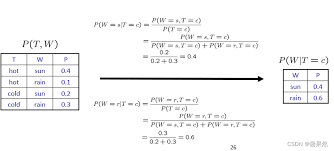`

## Probabilistic inference
- def - compute a desireed probability from other known probabilities (e.g. conditional from joint)
- Generally are computing conditional probabilities which represent the agent's beliefs given the evidence.

- Observing new evidence causes beliefs of the agent to be updated:
  - e.g. - P(on time | no accidents, 5 a.m.) = 0.95 -> P(on time | no accidents, 5 a.m., raining) = 0.80

### Inference by enumeration
- *Enumeration (in this context)* - exhaustive process of looking at the entire joint probability distribution and summing up specific rows to match the query.


* General Case Setup
* Evidence variables: $E_1 \dots E_k = e_1 \dots e_k$ (observed values)
   * Query variable: $Q$ (what we want to find out)
   * Hidden variables: $H_1 \dots H_r$ (unobserved variables that aren't the query)
   * All variables: $X_1, X_2, \dots X_n$
   * Goal: Calculate $P(Q|e_1 \dots e_k)$


* Step 1: Select Evidence
* Filter the full joint distribution table to keep only the entries consistent with the observed evidence $e$.
* Step 2: Sum Out Hidden Variables
* Marginalize (sum out) the hidden variables $H$ to find the joint probability of the query and the evidence:
   $$P(Q, e_1 \dots e_k) = \sum_{h_1 \dots h_r} P(Q, h_1 \dots h_r, e_1 \dots e_k)$$
* Step 3: Normalize
* Convert the resulting values into a valid probability distribution that sums to 1 using the normalization constant $Z$:
  
- $Z = \sum_{q} P(q, e_1 \dots e_k)$
  - Adding up joint probs for every possible outcome so that we can normalize by that
- $P(Q|e_1 \dots e_k) = \frac{1}{Z} P(Q, e_1 \dots e_k)$

- Obvious Problems
  - Worst-case time complexity is $O(d^n)$
  - Space complexity is also $O(d^n)$
    - `d` - maximum domain size (number of possible values) for any variable
    - `n` - total number of variables in the joint distribution






## Product Rule
- Sometimes we want to convert conditional distributions to joint
- P(y)P(x|y) = P(x,y)
- P(x|y) = $\frac{P(x,y)}{P(y)}$

## Chain rule
- You can always write any joint distribution as an incremental product of conditional distributions:
- $P(x_1, x_2, x_3, x_4) = P(x_1)P(x_2|x_1)P(x_3|x_1, x_2)P(x_4|x_1, x_2, x_3)$
  - More generally: $ P(x_1, x_2, \dots, x_n) = \prod_i P(x_i | x_1 \dots x_{i-1}) $

## Bayes' Rule
- **One of the most important AI equations**
- Two ways to factor a joint distribution over two variables.
  - P(x,y) = P(x|y)P(y) = P(y|x)
- After some re-arranging we get:
  - $P(x|y) = \frac{P(y|x)}{P(y)} \cdot P(x)$
- Why this is helpful:
  - Lets us build one conditional from its reverse
  - Often, one conditional is tricky but the other one is simple
  - foundation of many systems we will see later
- It allows us to get diagnostic probability from causal probability.

## Ghostbusters Problem
- Sensor reading tells how close a square i to the ghost
- `G` is random variable that represents where the ghost is on the grid.
- Each square represents the change there is a ghost there
- P(R|G)
  - R = reading color measured at (1,1)
  - ex. P(R=yellow |G=(1,1)) = 0.1
- *Prior Distribution P(G)* - Prior belief about the ghost location before you get any sensor reading.
- *Posterior Distribution P(G|R)* - The updated belief about the ghosts location after you observe the sensor reading.
  - We can calculate this given a reading using Bayes' rule:
    - P(G|R) α P(R|G)P(G)
